# Benchmark matrix — representations × partitions × models × seeds


## Goal
Build a realistic data-centric benchmark matrix in which conclusions can depend on both representation and partition regime. We compare three prepared feature spaces, two externally prepared partition scenarios, three model families plus a dummy baseline, repeated seeds and four metrics. The resulting tables support ranking, stability and interaction analysis.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("SABER_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from saber import benchmark
from saber.benchmark import BenchmarkConfig
from saber.datasets import DatasetBundle, PartitionPlan


In [2]:
rng=np.random.default_rng(303)
n=120 if DEMO_TEST else 280
X,y=make_classification(n_samples=n,n_features=14,n_informative=9,n_redundant=2,class_sep=1.0,random_state=303)
ids=np.asarray([f"matrix_{i:04d}" for i in range(n)],dtype=object)
rep1=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"R1_{i}" for i in range(X.shape[1])])
rep2_X=np.column_stack([X[:,:10],rng.normal(size=(n,14))]); rep2=DatasetBundle(X=rep2_X,y=y,sample_ids=ids,feature_names=[f"R2_{i}" for i in range(rep2_X.shape[1])])
rep3_X=np.tanh(X[:,:8]); rep3=DatasetBundle(X=rep3_X,y=y,sample_ids=ids,feature_names=[f"R3_{i}" for i in range(rep3_X.shape[1])])
plan_a=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=balanced_fold_labels(y,4),dataset_fingerprint=rep1.fingerprint,metadata={"source":"external","strategy":"balanced"})
# A deliberately different deterministic membership pattern to emulate a second upstream strategy.
order=np.argsort(X[:,0]); alt=np.empty(n,dtype=int); alt[order]=np.arange(n)%4
# Ensure every training membership retains both classes; if not, fall back to balanced labels for that demo artifact.
plan_b=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=alt,dataset_fingerprint=rep1.fingerprint,metadata={"source":"external","strategy":"feature_blocked_like"})


In [3]:
seeds=(42,) if DEMO_TEST else (42,123)
bench=benchmark(datasets={"rep_core":rep1,"rep_expanded":rep2,"rep_nonlinear":rep3},
                algorithms=("logistic_regression","random_forest","svc"),
                partitions={"balanced":plan_a,"feature_blocked":plan_b},
                config=BenchmarkConfig(metrics=("mcc","balanced_accuracy","f1","roc_auc"),seeds=seeds,modes=("untuned",),include_baselines=True),
                model_params={"random_forest":{"n_estimators":45 if DEMO_TEST else 110,"max_depth":7}})
assert not bench.failures
metrics=bench.aggregate_metrics_frame(); runs=bench.runs_frame(); folds=bench.fold_metrics_frame()
mcc=metrics[metrics.metric=="mcc"]
report=(mcc.groupby(["representation","partition","algorithm"])["score"].agg(["mean","std"]).reset_index())
report["rank"] = report.groupby(["representation","partition"])["mean"].rank(ascending=False,method="dense")
best=report[report["rank"]==1].sort_values(["partition","representation"])
best


,representation,partition,algorithm,mean,std,rank
3,rep_core,balanced,svc,0.746556,0.000000,1.0
10,rep_expanded,balanced,random_forest,0.495237,0.020814,1.0
19,rep_nonlinear,balanced,svc,0.468264,0.000000,1.0
7,rep_core,feature_blocked,svc,0.811846,0.000000,1.0
14,rep_expanded,feature_blocked,random_forest,0.525829,0.011539,1.0
22,rep_nonlinear,feature_blocked,random_forest,0.503774,0.001488,1.0


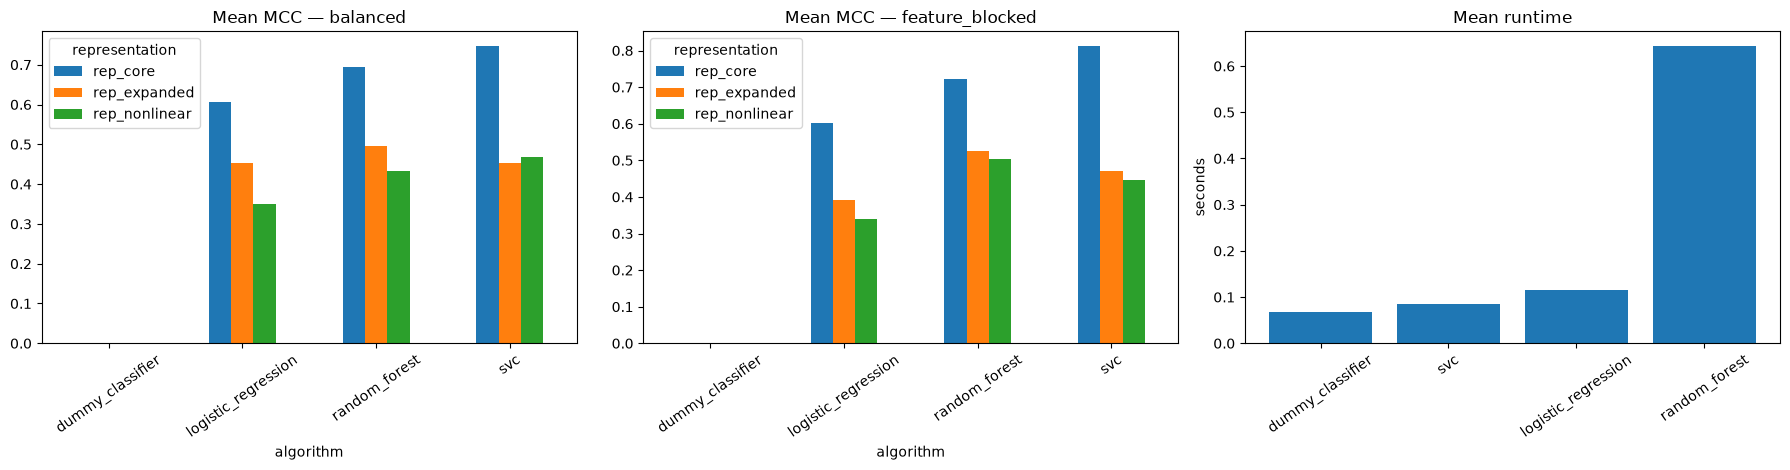

In [4]:
fig,axes=plt.subplots(1,3,figsize=(18,4.8))
for part,chunk in report.groupby("partition"):
    piv=chunk.pivot_table(index="algorithm",columns="representation",values="mean")
    # Plot only first two panels, one partition each.
    ax=axes[0] if part==sorted(report.partition.unique())[0] else axes[1]
    piv.plot.bar(ax=ax); ax.set_title(f"Mean MCC — {part}"); ax.tick_params(axis="x",rotation=35)
runtime=runs.groupby("algorithm")["elapsed_seconds"].mean().sort_values(); axes[2].bar(runtime.index,runtime.values); axes[2].set(title="Mean runtime",ylabel="seconds"); axes[2].tick_params(axis="x",rotation=35)
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
expected=3*2*4*len(seeds)
DEMO_CHECKS={
    "full_matrix":bench.n_runs==expected,
    "no_failures":len(bench.failures)==0,
    "two_partitions":set(report.partition)=={"balanced","feature_blocked"},
    "three_representations":report.representation.nunique()==3,
    "rankings_complete":report["rank"].notna().all(),
    "fold_metrics_available":not folds.empty,
    "figure_created":FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'full_matrix': True,
 'no_failures': True,
 'two_partitions': True,
 'three_representations': True,
 'rankings_complete': np.True_,
 'fold_metrics_available': True,
 'figure_created': True}